# Task 2: Exploratory Data Analysis

## Forecasting Financial Inclusion in Ethiopia

This notebook analyzes the enriched financial inclusion dataset to identify patterns, trends, data-quality limitations, and possible drivers of Access and Usage in Ethiopia.

The analysis focuses on:

- Dataset composition and temporal coverage
- Account Ownership trends
- Digital payment and mobile-money adoption
- Infrastructure and enabling factors
- Event-indicator relationships
- Correlations and leading indicators
- Data limitations and hypotheses for impact modeling

In [46]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [48]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

data_path = (
    project_root
    / "data"
    / "processed"
    / "ethiopia_fi_enriched.csv"
)

figures_path = project_root / "reports" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Dataset path:", data_path)
print("Figures path:", figures_path)

Project root: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast
Dataset path: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\data\processed\ethiopia_fi_enriched.csv
Figures path: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 11\ethiopia-fi-forecast\reports\figures


In [49]:
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (58, 35)


,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,impact_magnitude,indicator,indicator_code,indicator_direction,lag_months,location,notes,observation_date,original_text,parent_id,period_end,period_start,pillar,record_id,record_type,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2014-12-31,Baseline year,NaN,NaN,NaN,ACCESS,REC_0001,observation,NaN,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2017-12-31,NaN,NaN,NaN,NaN,ACCESS,REC_0002,observation,NaN,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,NaN,NaN,NaN,NaN,ACCESS,REC_0003,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,male,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,Gender disaggregated,NaN,NaN,NaN,ACCESS,REC_0004,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,56.0,NaN,percentage
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,female,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,Gender disaggregated,NaN,NaN,NaN,ACCESS,REC_0005,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,36.0,NaN,percentage


In [50]:
date_columns = [
    "observation_date",
    "period_start",
    "period_end",
    "collection_date"
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

df[date_columns].dtypes

observation_date    datetime64[us]
period_start        datetime64[us]
period_end          datetime64[us]
collection_date     datetime64[us]
dtype: object

In [51]:
# Start with the year from observation_date
df["analysis_year"] = (
    df["observation_date"]
    .dt.year
    .astype("Int64")
)

# Extract the first four-digit year from fiscal_year
fiscal_year_extracted = (
    df["fiscal_year"]
    .astype("string")
    .str.extract(r"(\d{4})", expand=False)
)

fiscal_year_extracted = pd.to_numeric(
    fiscal_year_extracted,
    errors="coerce"
).astype("Int64")

# Use fiscal year only where observation year is missing
df["analysis_year"] = df["analysis_year"].fillna(
    fiscal_year_extracted
)

df[
    [
        "record_id",
        "record_type",
        "indicator_code",
        "fiscal_year",
        "observation_date",
        "analysis_year"
    ]
].head(15)

,record_id,record_type,indicator_code,fiscal_year,observation_date,analysis_year
0,REC_0001,observation,ACC_OWNERSHIP,2014,2014-12-31,2014
1,REC_0002,observation,ACC_OWNERSHIP,2017,2017-12-31,2017
2,REC_0003,observation,ACC_OWNERSHIP,2021,2021-12-31,2021
3,REC_0004,observation,ACC_OWNERSHIP,2021,2021-12-31,2021
4,REC_0005,observation,ACC_OWNERSHIP,2021,2021-12-31,2021
5,REC_0006,observation,ACC_OWNERSHIP,2024,2024-11-29,2024
6,REC_0007,observation,ACC_MM_ACCOUNT,2021,2021-12-31,2021
7,REC_0008,observation,ACC_MM_ACCOUNT,2024,2024-11-29,2024
8,REC_0009,observation,ACC_4G_COV,FY2022/23,2023-06-30,2023
9,REC_0010,observation,ACC_4G_COV,FY2024/25,2025-06-30,2025


In [52]:
print("Missing analysis years:", df["analysis_year"].isna().sum())

df[
    df["analysis_year"].isna()
][
    [
        "record_id",
        "record_type",
        "indicator_code",
        "fiscal_year",
        "observation_date"
    ]
]

Missing analysis years: 0


,record_id,record_type,indicator_code,fiscal_year,observation_date


## 1. Dataset Overview

The unified dataset contains observations, events, impact links, and official targets. Dataset composition is examined by record type, financial inclusion pillar, source type, and confidence level.

In [53]:
record_type_summary = (
    df["record_type"]
    .value_counts(dropna=False)
    .rename_axis("record_type")
    .reset_index(name="record_count")
)

record_type_summary

,record_type,record_count
0,observation,31
1,impact_link,14
2,event,10
3,target,3


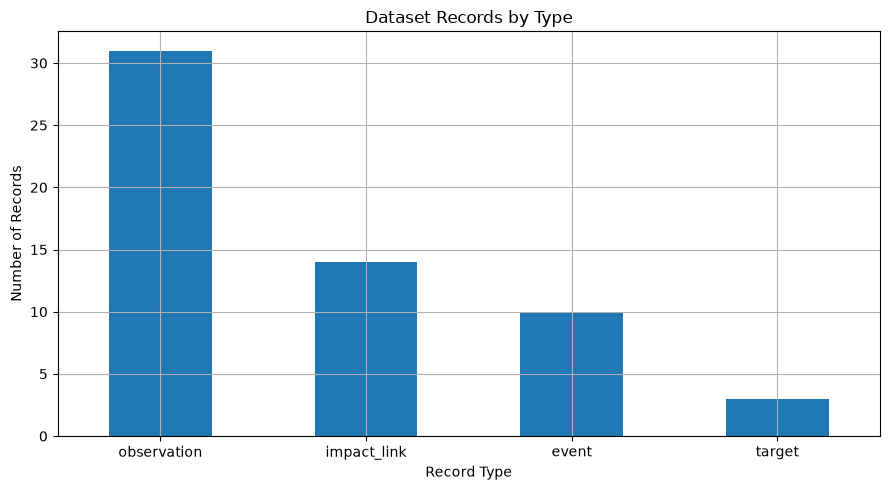

In [54]:
ax = record_type_summary.plot(
    kind="bar",
    x="record_type",
    y="record_count",
    legend=False,
    figsize=(9, 5)
)

ax.set_title("Dataset Records by Type")
ax.set_xlabel("Record Type")
ax.set_ylabel("Number of Records")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figures_path / "record_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
pillar_summary = (
    df["pillar"]
    .fillna("Not Assigned")
    .value_counts()
    .rename_axis("pillar")
    .reset_index(name="record_count")
)

pillar_summary

,pillar,record_count
0,ACCESS,21
1,USAGE,17
2,Not Assigned,10
3,GENDER,6
4,AFFORDABILITY,4


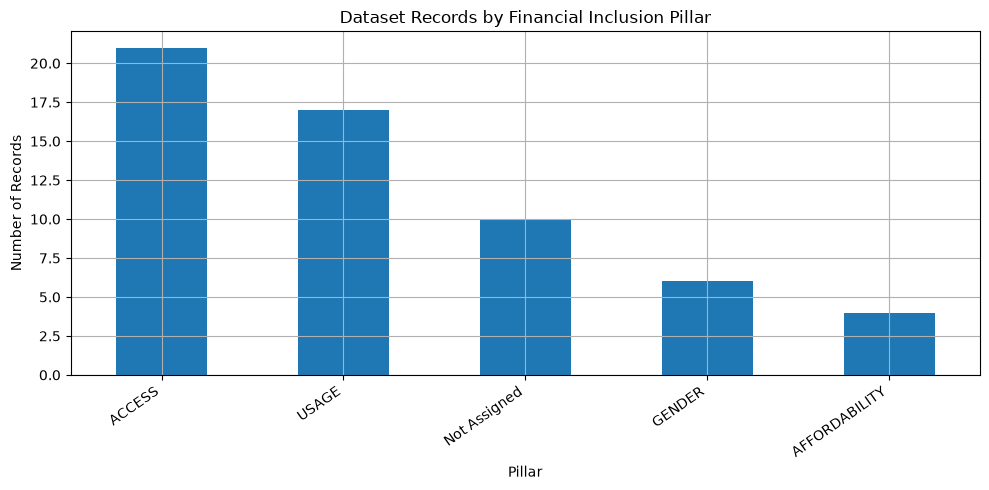

In [56]:
ax = pillar_summary.plot(
    kind="bar",
    x="pillar",
    y="record_count",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Dataset Records by Financial Inclusion Pillar")
ax.set_xlabel("Pillar")
ax.set_ylabel("Number of Records")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    figures_path / "pillar_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
source_type_summary = (
    df["source_type"]
    .fillna("Not Documented")
    .value_counts()
    .rename_axis("source_type")
    .reset_index(name="record_count")
)

source_type_summary

,source_type,record_count
0,operator,15
1,Not Documented,14
2,survey,11
3,regulator,7
4,research,4
5,policy,3
6,calculated,2
7,news,2


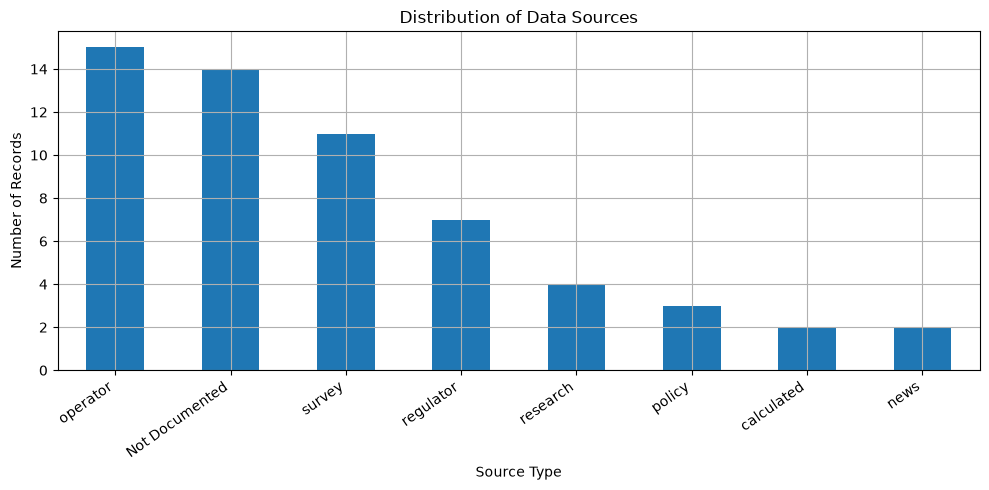

In [58]:
ax = source_type_summary.plot(
    kind="bar",
    x="source_type",
    y="record_count",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Distribution of Data Sources")
ax.set_xlabel("Source Type")
ax.set_ylabel("Number of Records")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    figures_path / "source_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2. Temporal Coverage

Temporal coverage is evaluated for measured observations. A coverage matrix shows which indicators have values in each year and highlights indicators with limited historical observations.

In [59]:
observations = df[
    df["record_type"] == "observation"
].copy()

observations = observations[
    observations["analysis_year"].notna()
].copy()

observations["analysis_year"] = (
    observations["analysis_year"]
    .astype(int)
)

print("Observation records:", len(observations))
print(
    "Observation period:",
    observations["analysis_year"].min(),
    "to",
    observations["analysis_year"].max()
)

Observation records: 31
Observation period: 2011 to 2025


In [60]:
indicator_coverage = (
    observations
    .groupby(
        [
            "indicator_code",
            "indicator"
        ],
        dropna=False
    )
    .agg(
        observation_count=("record_id", "count"),
        first_year=("analysis_year", "min"),
        last_year=("analysis_year", "max"),
        unique_years=("analysis_year", "nunique")
    )
    .reset_index()
    .sort_values(
        [
            "unique_years",
            "indicator_code"
        ],
        ascending=[
            False,
            True
        ]
    )
)

indicator_coverage

,indicator_code,indicator,observation_count,first_year,last_year,unique_years
4,ACC_OWNERSHIP,Account Ownership Rate,7,2011,2024,5
0,ACC_4G_COV,4G Population Coverage,2,2023,2025,2
1,ACC_FAYDA,Fayda Digital ID Enrollment,3,2024,2025,2
2,ACC_MM_ACCOUNT,Mobile Money Account Rate,2,2021,2024,2
6,GEN_GAP_ACC,Account Ownership Gender Gap,2,2021,2024,2
15,USG_P2P_COUNT,P2P Transaction Count,2,2024,2025,2
3,ACC_MOBILE_PEN,Mobile Subscription Penetration,1,2025,2025,1
5,AFF_DATA_INCOME,Data Affordability Index,1,2024,2024,1
7,GEN_GAP_MOBILE,Mobile Phone Gender Gap,1,2024,2024,1
8,GEN_MM_SHARE,Female Mobile Money Account Share,1,2024,2024,1


In [61]:
coverage_matrix = pd.crosstab(
    observations["indicator_code"],
    observations["analysis_year"]
)

coverage_matrix

analysis_year,2011,2014,2017,2021,2023,2024,2025
indicator_code,,,,,,,
ACC_4G_COV,0,0,0,0,1,0,1
ACC_FAYDA,0,0,0,0,0,1,2
ACC_MM_ACCOUNT,0,0,0,1,0,1,0
ACC_MOBILE_PEN,0,0,0,0,0,0,1
ACC_OWNERSHIP,1,1,1,3,0,1,0
AFF_DATA_INCOME,0,0,0,0,0,1,0
GEN_GAP_ACC,0,0,0,1,0,1,0
GEN_GAP_MOBILE,0,0,0,0,0,1,0
GEN_MM_SHARE,0,0,0,0,0,1,0


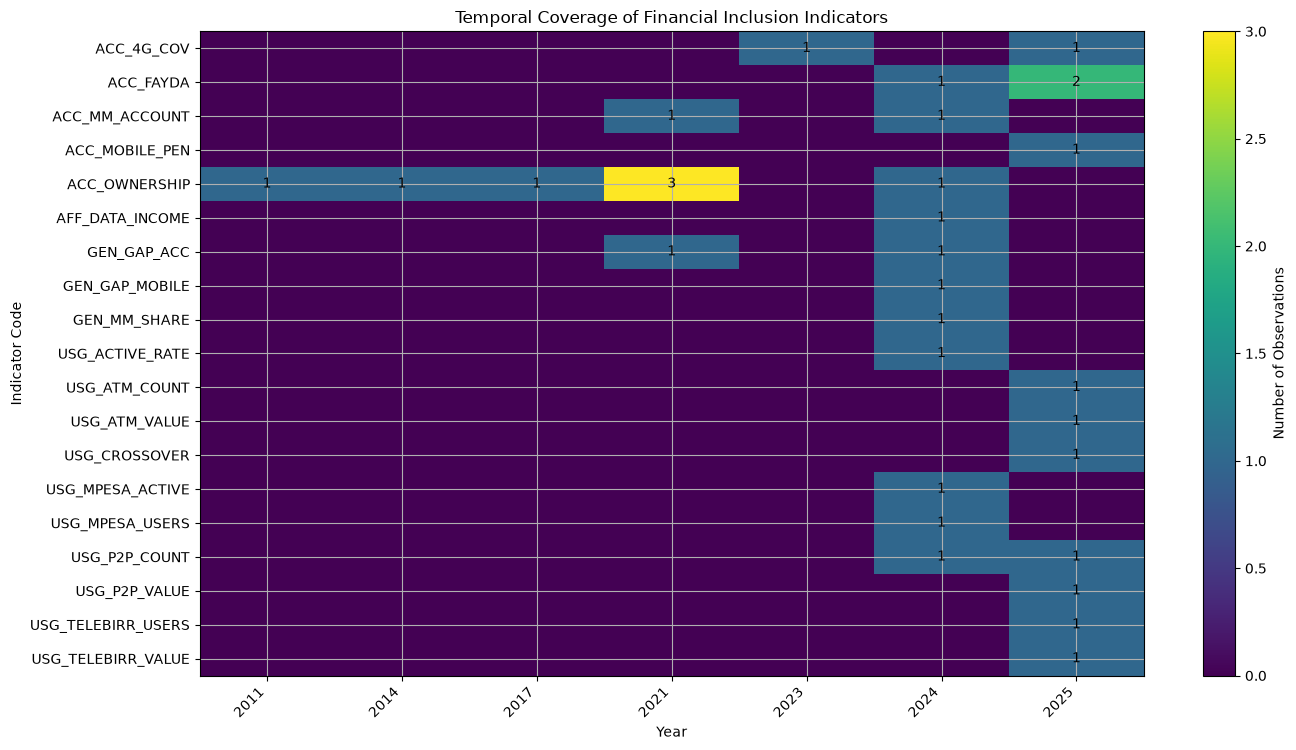

In [62]:
fig, ax = plt.subplots(
    figsize=(
        14,
        max(7, len(coverage_matrix) * 0.4)
    )
)

coverage_image = ax.imshow(
    coverage_matrix.values,
    aspect="auto"
)

ax.set_title(
    "Temporal Coverage of Financial Inclusion Indicators"
)

ax.set_xlabel("Year")
ax.set_ylabel("Indicator Code")

ax.set_xticks(
    range(len(coverage_matrix.columns))
)

ax.set_xticklabels(
    coverage_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(coverage_matrix.index))
)

ax.set_yticklabels(
    coverage_matrix.index
)

for row_index in range(
    coverage_matrix.shape[0]
):
    for column_index in range(
        coverage_matrix.shape[1]
    ):
        value = coverage_matrix.iloc[
            row_index,
            column_index
        ]

        if value > 0:
            ax.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center"
            )

fig.colorbar(
    coverage_image,
    ax=ax,
    label="Number of Observations"
)

plt.tight_layout()

plt.savefig(
    figures_path / "indicator_temporal_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Data Quality Assessment

Confidence classifications provide an indication of source reliability and uncertainty. The analysis also identifies indicators with sparse historical coverage, missing values, and limitations that may affect later modeling.

In [63]:
confidence_summary = (
    df["confidence"]
    .fillna("Not Documented")
    .value_counts()
    .rename_axis("confidence")
    .reset_index(name="record_count")
)

confidence_summary

,confidence,record_count
0,high,45
1,medium,13


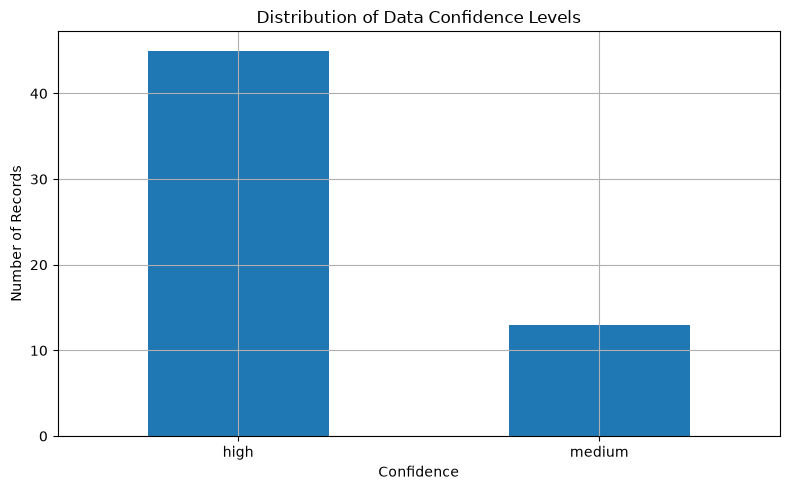

In [64]:
ax = confidence_summary.plot(
    kind="bar",
    x="confidence",
    y="record_count",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("Distribution of Data Confidence Levels")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of Records")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figures_path / "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
sparse_indicators = indicator_coverage[
    indicator_coverage["unique_years"] <= 2
].copy()

print(
    "Indicators with two or fewer observed years:",
    len(sparse_indicators)
)

sparse_indicators

Indicators with two or fewer observed years: 18


,indicator_code,indicator,observation_count,first_year,last_year,unique_years
0,ACC_4G_COV,4G Population Coverage,2,2023,2025,2
1,ACC_FAYDA,Fayda Digital ID Enrollment,3,2024,2025,2
2,ACC_MM_ACCOUNT,Mobile Money Account Rate,2,2021,2024,2
6,GEN_GAP_ACC,Account Ownership Gender Gap,2,2021,2024,2
15,USG_P2P_COUNT,P2P Transaction Count,2,2024,2025,2
3,ACC_MOBILE_PEN,Mobile Subscription Penetration,1,2025,2025,1
5,AFF_DATA_INCOME,Data Affordability Index,1,2024,2024,1
7,GEN_GAP_MOBILE,Mobile Phone Gender Gap,1,2024,2024,1
8,GEN_MM_SHARE,Female Mobile Money Account Share,1,2024,2024,1
9,USG_ACTIVE_RATE,Mobile Money Activity Rate,1,2024,2024,1


In [66]:
important_columns = [
    "record_id",
    "record_type",
    "pillar",
    "indicator_code",
    "value_numeric",
    "observation_date",
    "source_name",
    "source_url",
    "confidence"
]

missing_summary = (
    df[important_columns]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
).round(1)

missing_summary

,missing_count,missing_percentage
record_id,0,0.0
record_type,0,0.0
pillar,10,17.2
indicator_code,14,24.1
value_numeric,12,20.7
observation_date,0,0.0
source_name,14,24.1
source_url,26,44.8
confidence,0,0.0


In [67]:
quality_findings = pd.DataFrame({
    "quality_dimension": [
        "Dataset size",
        "Observed indicators",
        "Sparse indicators",
        "Temporal consistency",
        "Source confidence",
        "Forecasting limitation"
    ],
    "finding": [
        f"The enriched dataset contains {len(df)} total records.",
        (
            f"The dataset contains "
            f"{observations['indicator_code'].nunique()} "
            "observed indicators."
        ),
        (
            f"{len(sparse_indicators)} indicators have "
            "observations in two or fewer years."
        ),
        (
            "Most indicators do not have continuous annual "
            "time-series coverage."
        ),
        (
            f"{(df['confidence'] == 'high').sum()} records "
            "are classified as high confidence."
        ),
        (
            "Account Ownership has only five national survey "
            "points between 2011 and 2024."
        )
    ]
})

quality_findings

,quality_dimension,finding
0,Dataset size,The enriched dataset contains 58 total records.
1,Observed indicators,The dataset contains 19 observed indicators.
2,Sparse indicators,18 indicators have observations in two or fewe...
3,Temporal consistency,Most indicators do not have continuous annual ...
4,Source confidence,45 records are classified as high confidence.
5,Forecasting limitation,Account Ownership has only five national surve...


### Initial Data-Quality Interpretation

The dataset combines demand-side survey measurements, operator reports, infrastructure statistics, events, targets, and modeled impact links. This provides broad contextual coverage, but most indicators have only one or two recorded years.

The strongest historical series is national Account Ownership, which contains five survey observations from 2011 to 2024. Even this series remains too sparse for complex time-series modeling without strong assumptions.

Operator indicators such as registered mobile-money users and transaction values may provide more current market information, but they are not directly equivalent to survey-reported adult usage. Registered accounts can include inactive, duplicate, or multi-account users.

The absence of continuous annual observations means that later correlation and forecasting results should be interpreted as exploratory associations rather than causal evidence.

## 4. Access and Usage Indicators

This section explores Ethiopia's financial inclusion indicators over time, focusing on account ownership, digital payment adoption, mobile-money growth, and enabling infrastructure.

In [68]:
account_ownership = observations[
    (observations["indicator_code"] == "ACC_OWNERSHIP") &
    (observations["gender"] == "all")
].sort_values("analysis_year")

account_ownership[
    [
        "analysis_year",
        "value_numeric"
    ]
]

,analysis_year,value_numeric
57,2011,14.0
0,2014,22.0
1,2017,35.0
2,2021,46.0
5,2024,49.0


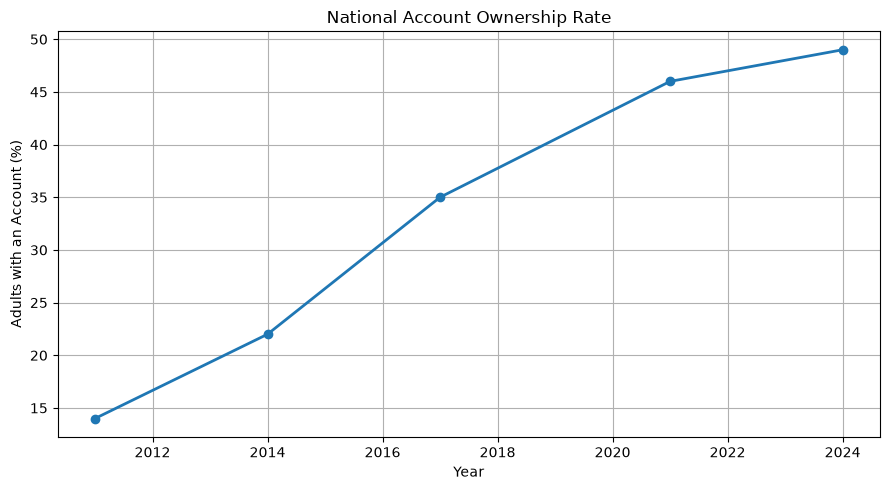

In [69]:
plt.figure(figsize=(9,5))

plt.plot(
    account_ownership["analysis_year"],
    account_ownership["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("National Account Ownership Rate")
plt.xlabel("Year")
plt.ylabel("Adults with an Account (%)")

plt.tight_layout()

plt.savefig(
    figures_path / "account_ownership_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
account_ownership = account_ownership.copy()

account_ownership["growth"] = (
    account_ownership["value_numeric"]
    .diff()
)

account_ownership

,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,impact_magnitude,indicator,indicator_code,indicator_direction,lag_months,location,notes,observation_date,original_text,parent_id,period_end,period_start,pillar,record_id,record_type,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type,analysis_year,growth
57,NaN,Bilen M. Gebremariam,2026-07-18,NaN,high,NaN,2011,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,increase,NaN,Ethiopia,Added as the missing baseline required to anal...,2011-12-31,Ethiopia's account ownership rate in 2011 was ...,NaN,2011-12-31,2011-01-01,ACCESS,REC_0058,observation,NaN,NaN,NaN,World Bank Global Findex 2011,survey,https://datatopics.worldbank.org/financialincl...,percent,14.0,NaN,percentage,2011,NaN
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2014-12-31,Baseline year,NaN,NaT,NaT,ACCESS,REC_0001,observation,NaN,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage,2014,8.0
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2017-12-31,NaN,NaN,NaT,NaT,ACCESS,REC_0002,observation,NaN,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage,2017,13.0
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2021-12-31,NaN,NaN,NaT,NaT,ACCESS,REC_0003,observation,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage,2021,11.0
5,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2024,all,NaN,NaN,NaN,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,national,NaN,2024-11-29,Survey Oct-Nov 2024,NaN,2024-11-29,2024-10-15,ACCESS,REC_0006,observation,NaN,NaN,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,%,49.0,NaN,percentage,2024,3.0


### Interpretation

Account ownership increased steadily between 2011 and 2021 before growth slowed between 2021 and 2024. This suggests Ethiopia experienced rapid expansion during the early financial inclusion reforms, followed by a period of slower market maturation.

In [71]:
digital_payment_codes = [
    "ACC_MM_ACCOUNT",
    "USG_ACTIVE_RATE",
    "USG_P2P_COUNT",
    "USG_P2P_VALUE",
    "USG_TELEBIRR_USERS",
    "USG_TELEBIRR_VALUE",
    "USG_MPESA_USERS",
    "USG_MPESA_ACTIVE"
]

digital_payment = observations[
    observations["indicator_code"].isin(
        digital_payment_codes
    )
].copy()

digital_payment["value_numeric"] = pd.to_numeric(
    digital_payment["value_numeric"],
    errors="coerce"
)

digital_payment[
    [
        "analysis_year",
        "indicator_code",
        "indicator",
        "value_numeric",
        "unit"
    ]
].sort_values(
    [
        "indicator",
        "analysis_year"
    ]
)

,analysis_year,indicator_code,indicator,value_numeric,unit
23,2024,USG_MPESA_ACTIVE,M-Pesa 90-Day Active Users,7.100000e+06,users
22,2024,USG_MPESA_USERS,M-Pesa Registered Users,1.080000e+07,users
6,2021,ACC_MM_ACCOUNT,Mobile Money Account Rate,4.700000e+00,%
7,2024,ACC_MM_ACCOUNT,Mobile Money Account Rate,9.450000e+00,%
24,2024,USG_ACTIVE_RATE,Mobile Money Activity Rate,6.600000e+01,%
14,2024,USG_P2P_COUNT,P2P Transaction Count,4.970000e+07,transactions
15,2025,USG_P2P_COUNT,P2P Transaction Count,1.283000e+08,transactions
16,2025,USG_P2P_VALUE,P2P Transaction Value,5.777000e+11,ETB
20,2025,USG_TELEBIRR_USERS,Telebirr Registered Users,5.484000e+07,users
21,2025,USG_TELEBIRR_VALUE,Telebirr Transaction Value,2.380000e+12,ETB


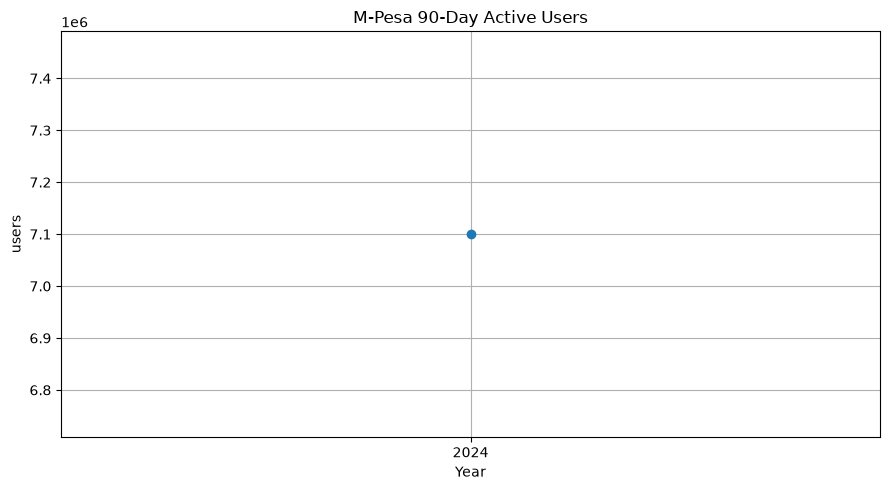

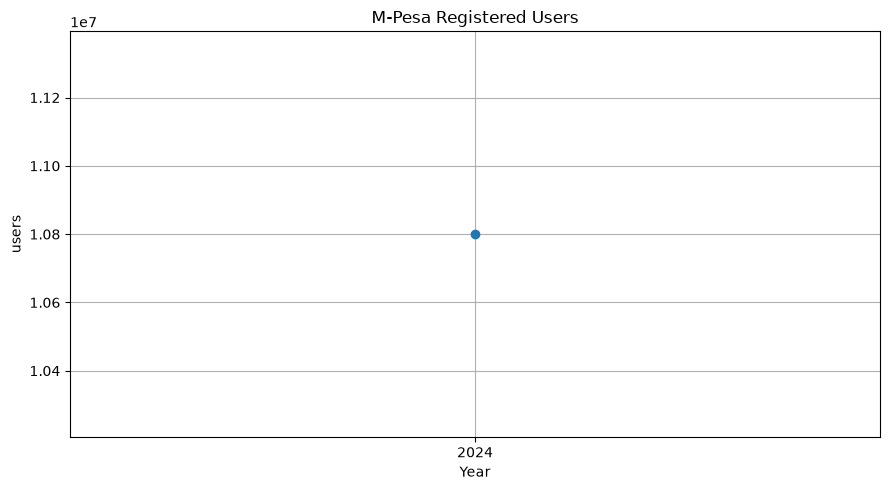

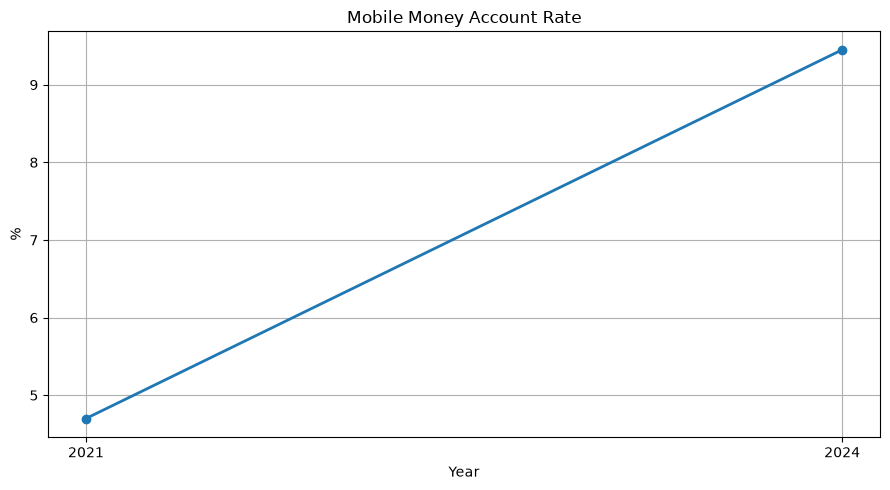

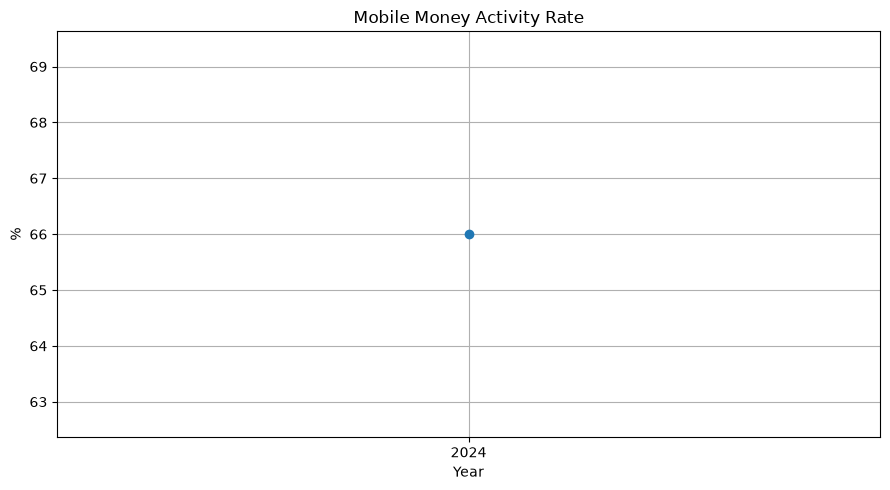

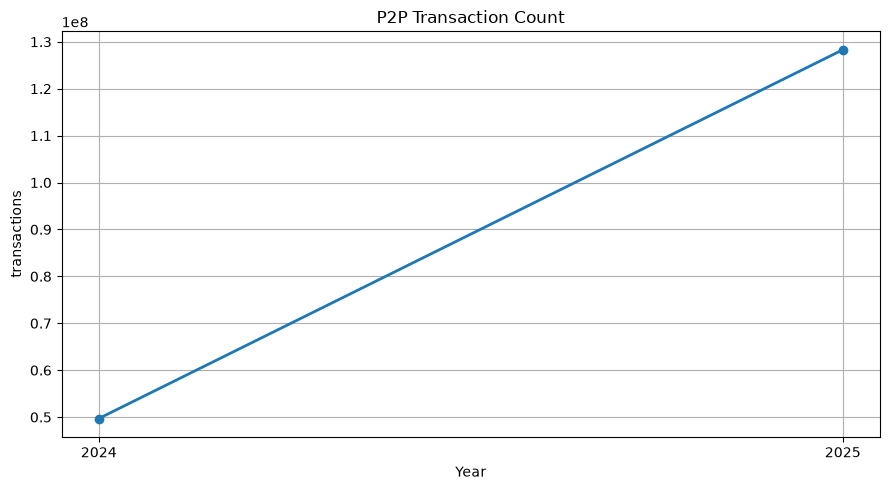

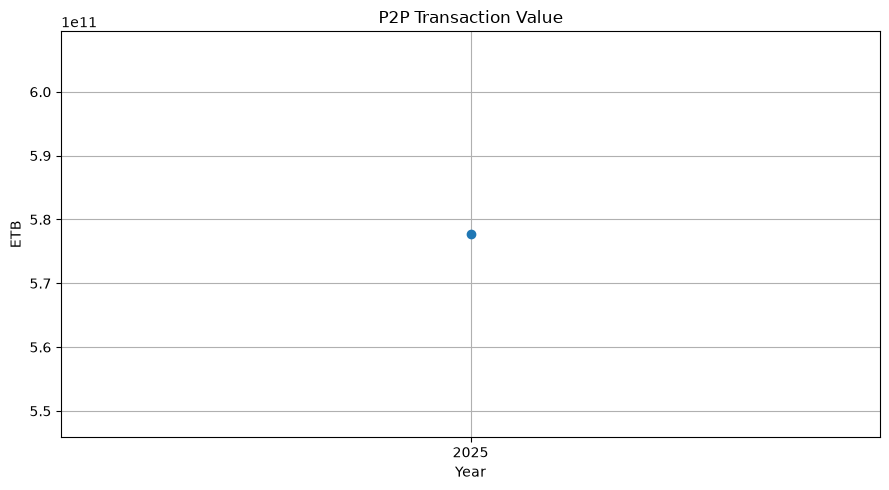

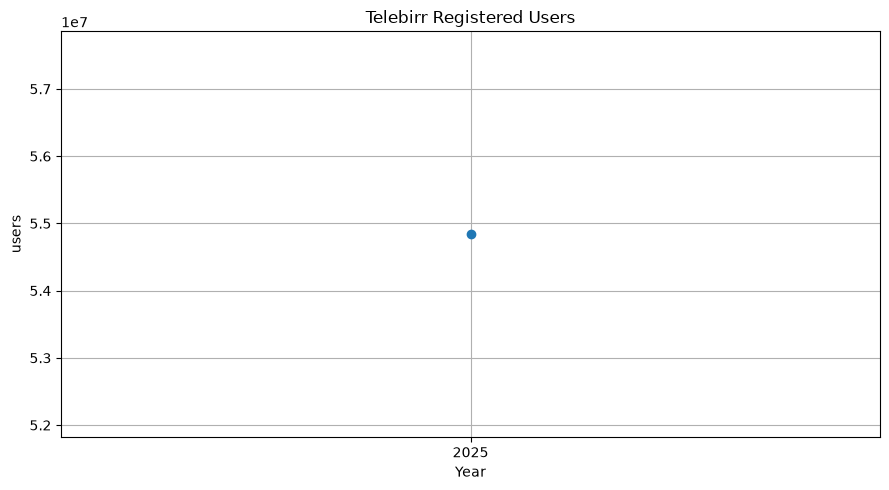

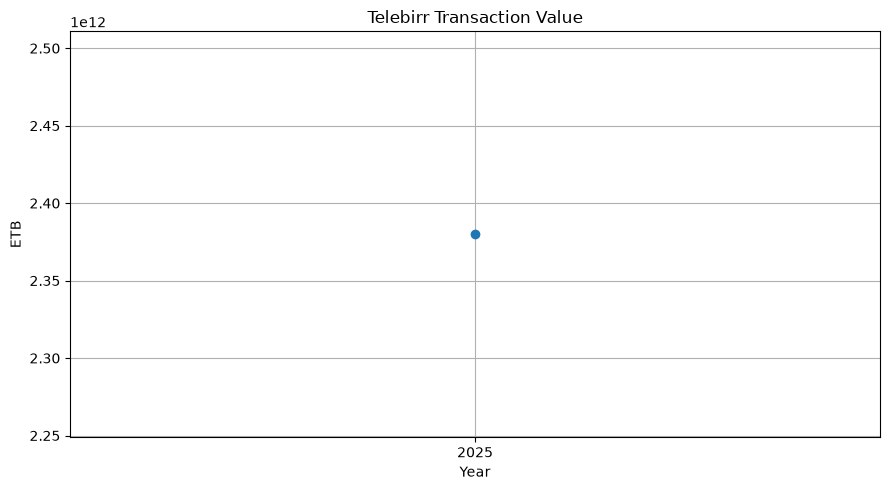

Digital indicator charts created: 8


In [72]:
digital_chart_count = 0

for indicator_name, indicator_data in digital_payment.groupby(
    "indicator"
):
    indicator_data = indicator_data.dropna(
        subset=[
            "analysis_year",
            "value_numeric"
        ]
    ).sort_values("analysis_year")

    if indicator_data.empty:
        continue

    plt.figure(figsize=(9, 5))

    plt.plot(
        indicator_data["analysis_year"],
        indicator_data["value_numeric"],
        marker="o",
        linewidth=2
    )

    units = indicator_data["unit"].dropna()
    ylabel = (
        units.iloc[0]
        if not units.empty
        else "Reported Value"
    )

    plt.title(indicator_name)
    plt.xlabel("Year")
    plt.ylabel(ylabel)

    plt.xticks(
        indicator_data["analysis_year"]
    )

    plt.tight_layout()

    safe_name = (
        indicator_name.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

    plt.savefig(
        figures_path / f"digital_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    digital_chart_count += 1

print(
    "Digital indicator charts created:",
    digital_chart_count
)

In [77]:
infrastructure_codes = [
    "ACC_4G_COV",
    "ACC_FAYDA",
    "ACC_MOBILE_PEN",
    "AFF_DATA_INCOME"
]

infrastructure = observations[
    observations["indicator_code"].isin(
        infrastructure_codes
    )
].copy()

infrastructure["value_numeric"] = pd.to_numeric(
    infrastructure["value_numeric"],
    errors="coerce"
)

infrastructure[
    [
        "analysis_year",
        "indicator_code",
        "indicator",
        "value_numeric",
        "unit"
    ]
].sort_values(
    [
        "indicator",
        "analysis_year"
    ]
)

,analysis_year,indicator_code,indicator,value_numeric,unit
8,2023,ACC_4G_COV,4G Population Coverage,37.5,%
9,2025,ACC_4G_COV,4G Population Coverage,70.8,%
25,2024,AFF_DATA_INCOME,Data Affordability Index,2.0,% of GNI
11,2024,ACC_FAYDA,Fayda Digital ID Enrollment,8000000.0,people
12,2025,ACC_FAYDA,Fayda Digital ID Enrollment,12000000.0,people
13,2025,ACC_FAYDA,Fayda Digital ID Enrollment,15000000.0,people
10,2025,ACC_MOBILE_PEN,Mobile Subscription Penetration,61.4,%


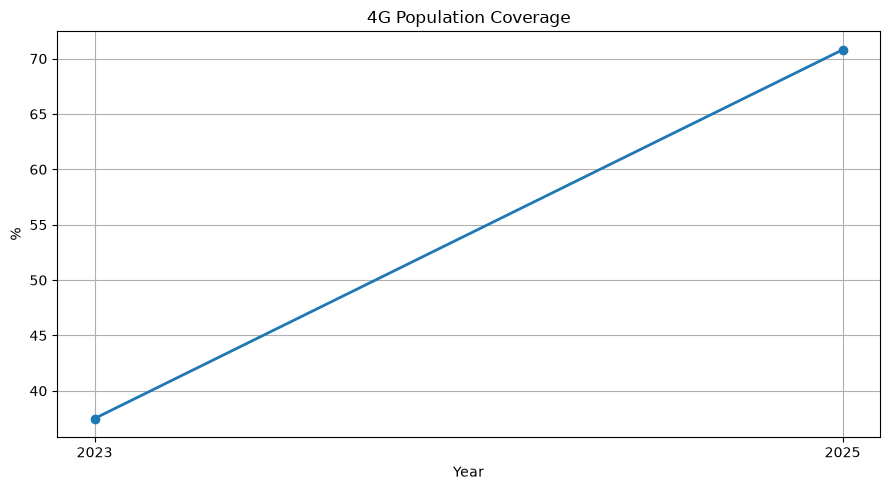

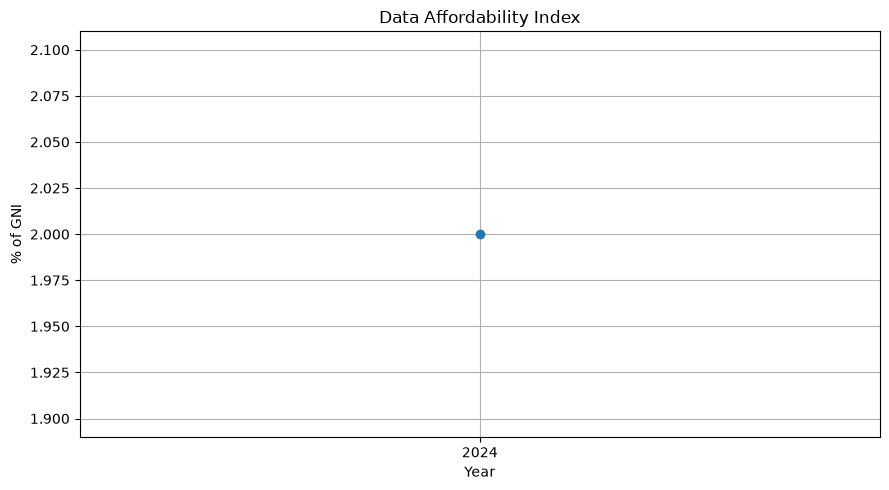

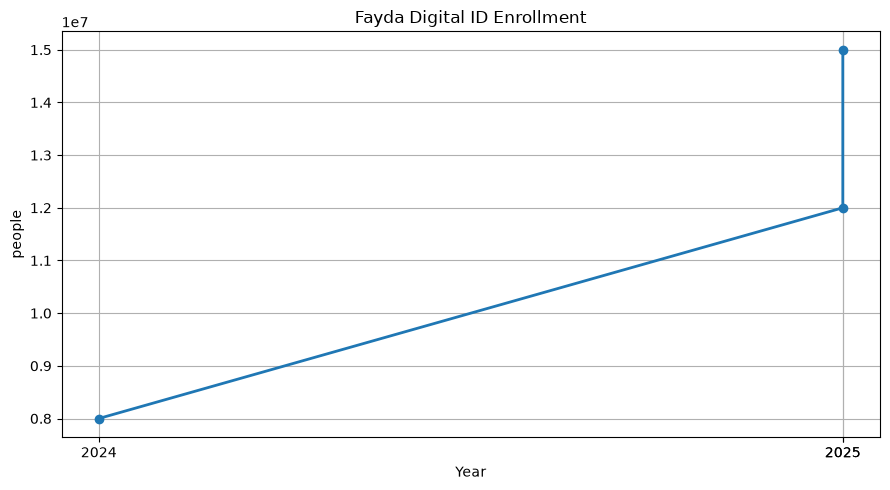

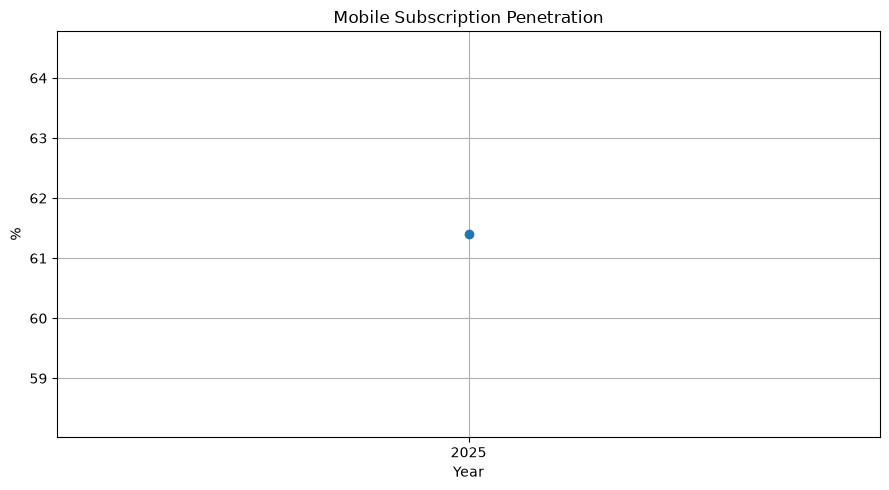

Infrastructure charts created: 4


In [78]:
infrastructure_chart_count = 0

for indicator_name, indicator_data in infrastructure.groupby(
    "indicator"
):
    indicator_data = indicator_data.dropna(
        subset=[
            "analysis_year",
            "value_numeric"
        ]
    ).sort_values("analysis_year")

    if indicator_data.empty:
        continue

    plt.figure(figsize=(9, 5))

    plt.plot(
        indicator_data["analysis_year"],
        indicator_data["value_numeric"],
        marker="o",
        linewidth=2
    )

    units = indicator_data["unit"].dropna()
    ylabel = (
        units.iloc[0]
        if not units.empty
        else "Reported Value"
    )

    plt.title(indicator_name)
    plt.xlabel("Year")
    plt.ylabel(ylabel)

    plt.xticks(
        indicator_data["analysis_year"]
    )

    plt.tight_layout()

    safe_name = (
        indicator_name.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

    plt.savefig(
        figures_path
        / f"infrastructure_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    infrastructure_chart_count += 1

print(
    "Infrastructure charts created:",
    infrastructure_chart_count
)

In [79]:
indicator_summary = (
    observations.groupby("indicator")
    .agg(
        observations=("record_id","count"),
        first_year=("analysis_year","min"),
        last_year=("analysis_year","max"),
        average=("value_numeric","mean")
    )
    .round(2)
    .sort_values("observations",ascending=False)
)

indicator_summary

,observations,first_year,last_year,average
indicator,,,,
Account Ownership Rate,7,2011,2024,3.686000e+01
Fayda Digital ID Enrollment,3,2024,2025,1.166667e+07
4G Population Coverage,2,2023,2025,5.415000e+01
P2P Transaction Count,2,2024,2025,8.900000e+07
Mobile Money Account Rate,2,2021,2024,7.070000e+00
Account Ownership Gender Gap,2,2021,2024,1.900000e+01
ATM Transaction Count,1,2025,2025,1.193000e+08
ATM Transaction Value,1,2025,2025,1.561000e+11
Data Affordability Index,1,2024,2024,2.000000e+00


In [80]:
findings = pd.DataFrame({
    "Finding": [
        (
            "National account ownership increased from "
            "14% in 2011 to 49% in 2024."
        ),
        (
            "Account ownership growth slowed from a "
            "11-percentage-point increase during 2017–2021 "
            "to only 3 points during 2021–2024."
        ),
        (
            "Mobile-money, P2P transaction, and operator "
            "indicators suggest rapid recent digital-finance "
            "expansion."
        ),
        (
            "4G coverage, mobile penetration, digital ID, "
            "and affordability indicators provide evidence "
            "about the enabling environment."
        ),
        (
            "Most digital-finance and infrastructure "
            "indicators have only one or two observed years."
        )
    ]
})

findings

,Finding
0,National account ownership increased from 14% ...
1,Account ownership growth slowed from a 11-perc...
2,"Mobile-money, P2P transaction, and operator in..."
3,"4G coverage, mobile penetration, digital ID, a..."
4,Most digital-finance and infrastructure indica...


### Interpretation

National account ownership increased from 14% in 2011 to 49% in 2024. The largest gains occurred before 2021, while the increase from 46% in 2021 to 49% in 2024 was comparatively small.

The dataset also records rapid recent expansion in mobile-money registrations, peer-to-peer transactions, digital identification, mobile coverage, and other enabling indicators. However, many of these variables are available for only one or two years and use different measurement units.

These indicators therefore provide useful contextual evidence of digital-finance expansion, but they cannot yet support strong statistical conclusions about long-term trends or causality.